In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results_dir = Path("../results")

In [3]:
with open(results_dir / "logistic_regression_metrics.json") as f:
    lr_metrics = json.load(f)

with open(results_dir / "decision_tree_metrics.json") as f:
    dt_metrics = json.load(f)

with open(results_dir / "random_forest_metrics.json") as f:
    rf_metrics = json.load(f)

with open(results_dir / "xgboost_metrics.json") as f:
    xgb_metrics = json.load(f)

In [5]:
comparison_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics])
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.796731,0.637500,0.545455,0.587896,0.830471
1,Decision Tree,0.727079,0.486979,0.500000,0.493404,0.656087
2,Random Forest,0.783227,0.623656,0.465241,0.532925,0.806819
3,XGBoost,0.786070,0.618893,0.508021,0.558003,0.804683


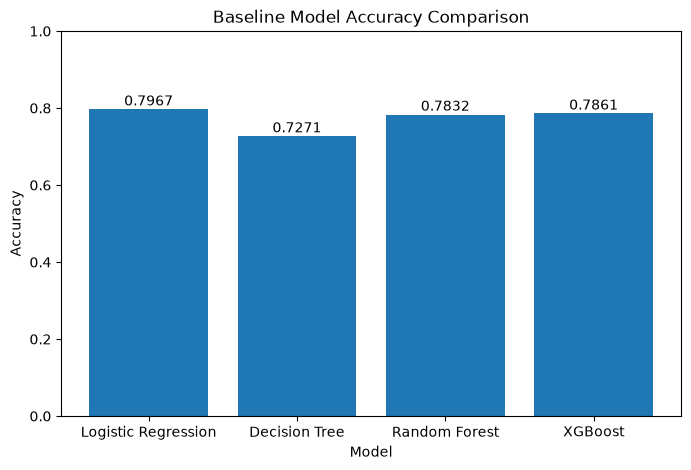

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)
plt.title("Baseline Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")
plt.show()

### Observation

Logistic Regression achieved the highest accuracy (0.7967) among all baseline models, followed closely by XGBoost and Random Forest. Decision Tree recorded the lowest accuracy, indicating that ensemble methods and Logistic Regression generalized better on this dataset.

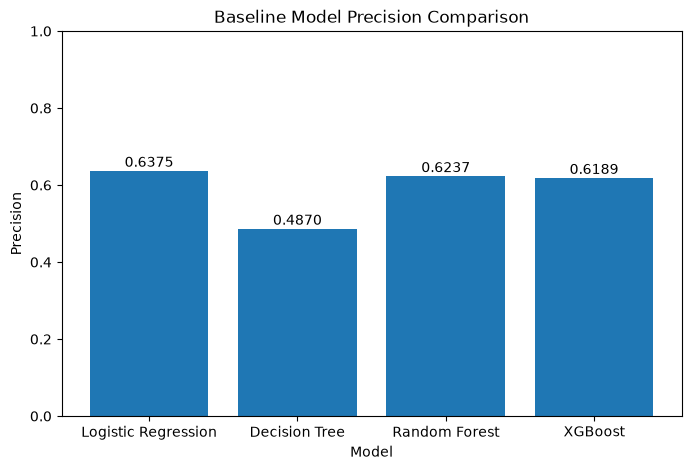

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"]
)
plt.title("Baseline Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["Precision"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.show()

### Observation

Logistic Regression achieved the highest precision, meaning it produced the fewest false positives when predicting customer churn. Random Forest and XGBoost performed similarly, while Decision Tree had the lowest precision.

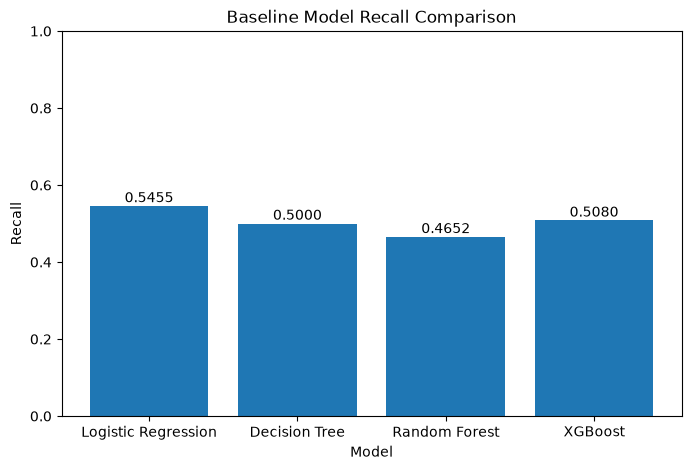

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)
plt.title("Baseline Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["Recall"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.show()

### Observation

Logistic Regression achieved the highest recall, successfully identifying the largest proportion of customers who were likely to churn. XGBoost ranked second, while Random Forest and Decision Tree identified fewer churn cases.

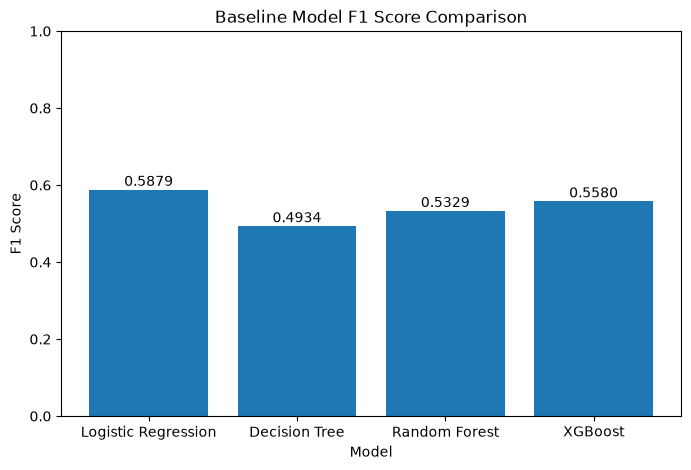

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)
plt.title("Baseline Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["F1 Score"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")
plt.show()

### Observation

Logistic Regression achieved the highest F1 Score, indicating the best balance between precision and recall. XGBoost and Random Forest followed with competitive performance, whereas Decision Tree produced the weakest overall balance.

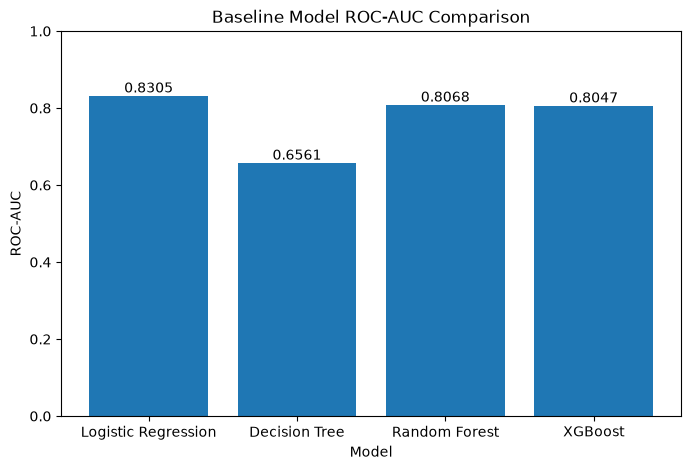

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"]
)
plt.title("Baseline Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["ROC-AUC"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")
plt.show()

### Observation

Logistic Regression achieved the highest ROC-AUC score (0.8305), demonstrating the strongest ability to distinguish between churn and non-churn customers. Random Forest and XGBoost also showed strong discrimination capability, while Decision Tree performed significantly worse.

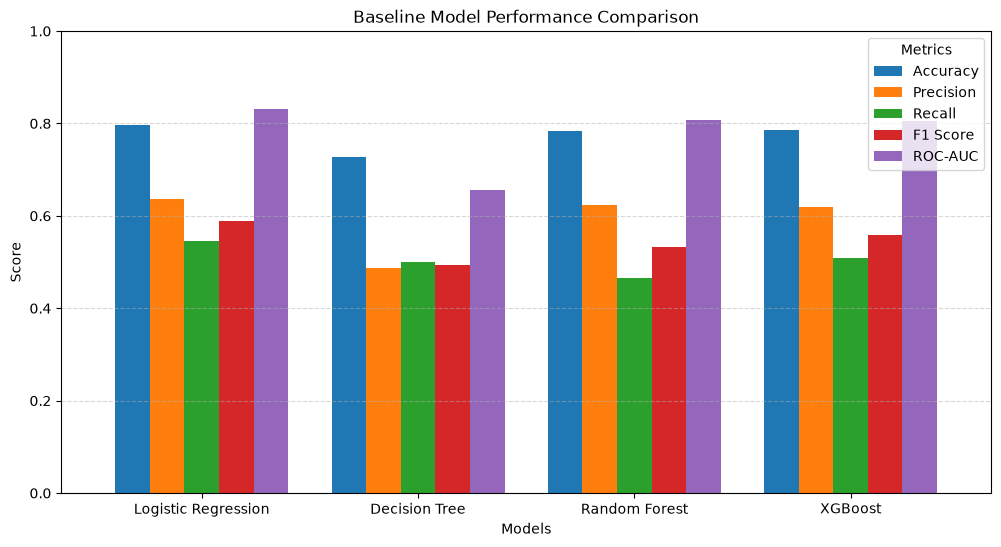

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison_plot = comparison_df.set_index("Model")[metrics]
ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Observation

The grouped bar chart provides an overall comparison of all baseline models across the five evaluation metrics. Logistic Regression consistently achieved the highest scores, while Random Forest and XGBoost demonstrated competitive performance. Decision Tree performed noticeably worse than the other models across all evaluation metrics.

In [15]:
ranking_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

ranking_df.index = ranking_df.index + 1

ranking_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.796731,0.637500,0.545455,0.587896,0.830471
2,Random Forest,0.783227,0.623656,0.465241,0.532925,0.806819
3,XGBoost,0.786070,0.618893,0.508021,0.558003,0.804683
4,Decision Tree,0.727079,0.486979,0.500000,0.493404,0.656087


### Observation:

Based on the ROC-AUC score, Logistic Regression achieved the highest performance among all baseline models. Random Forest ranked second, followed closely by XGBoost, with only a marginal difference in ROC-AUC. Decision Tree showed the weakest performance, indicating that it may require tuning or pruning to improve its generalization ability.